<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; width: auto; max-width: 100%;">
<h1 style="color: white;"> ПРАКТИЧЕСКАЯ РАБОТА № 1</h1>
<h2 style="color: white;">Анализ ИТ-бюджета и прогнозирование затрат</h2>
</div>

---

##  Цель работы

> Научиться анализировать исторические данные о затратах на ИТ-проекты 
> и строить прогноз бюджета на следующий год.

---

## Описание данных

Набор данных: **`it_projects_budget_data.csv`**

| Поле | Описание |
|------|----------|
| `project_id` | Идентификатор проекта |
| `start_date` | Дата начала проекта |
| `end_date` | Дата завершения проекта |
| `department` | Подразделение-заказчик |
| `category` | Категория проекта (инфраструктура, разработка ПО, безопасность и т.д.) |
| `budget_planned` | Плановый бюджет проекта |
| `budget_actual` | Фактический бюджет проекта |
| `success_rate` | Оценка успешности проекта (0–1) |

---


## 1. Импорт библиотек

На данном этапе загружаются все необходимые библиотеки для анализа данных и прогнозирования бюджета.

###  Работа с данными
- **`pandas`** — загрузка, обработка и анализ табличных данных
- **`numpy`** — математические операции и работа с массивами

### Визуализация
- **`matplotlib.pyplot`** — построение графиков
- **`seaborn`** — статистические визуализации
- **`IPython.display`** — расширенный вывод данных в Jupyter

###  Статистический анализ и прогнозирование
- **`scipy.stats`** — преобразование Бокса-Кокса для стабилизации дисперсии
- **`statsmodels.api`** — модели SARIMAX для прогнозирования временных рядов
- **`pmdarima.auto_arima`** — автоматический подбор параметров SARIMA

###  Машинное обучение
- **`xgboost.XGBRegressor`** — градиентный бустинг для прогнозирования
- **`sklearn.linear_model.LinearRegression`** — линейная регрессия для прогнозирования тренда

###  Работа с датами
- **`dateutil.relativedelta`** — генерация дат для прогнозного периода

###  Настройки окружения
- **`warnings.filterwarnings('ignore')`** — отключение предупреждений для чистоты вывода
- **`%config Completer.use_jedi = True`** — использование Jedi для интеллектуального автодополнения
- **`%config Completer.greedy = True`** — агрессивный режим подсказок (срабатывает чаще)

###  Вспомогательная функция
```python
def invboxcox(y, lmbda):
    if lmbda == 0:
        return np.exp(y)
    else:
        return np.exp(np.log(lmbda * y + 1) / lmbda)

In [2]:

import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

from scipy import stats
from pmdarima import auto_arima
from xgboost import XGBRegressor
from dateutil.relativedelta import relativedelta



import statsmodels.api as sm
from imblearn import over_sampling
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import classification_report, f1_score

import warnings
warnings.filterwarnings('ignore')

def invboxcox(y,lmbda):
   if lmbda == 0:
      return(np.exp(y))
   else:
      return(np.exp(np.log(lmbda*y+1)/lmbda))

%config Completer.use_jedi = True
%config Completer.greedy = True

## 2. Загрузка данных

Выполняется загрузка исходного датасета с информацией о завершенных ИТ-проектах компании.

```python
data1_df = pd.read_csv("it_projects_budget_data.csv")


In [ ]:
data1_df = pd.read_csv("it_projects_budget_data.csv")

#### Первичный просмотр данных

Смотрим первый 10 строк 

```python
data1_df.head(10)

In [4]:
data1_df.head(10)

,project_id,start_date,end_date,department,category,budget_planned,budget_actual,success_rate
0,PRJ0001,2025-12-18,2026-06-16,IT,Security,1262214.68,1097835.15,1.000
1,PRJ0002,2025-07-25,2025-12-22,Operations,Data Analytics,207324.26,175572.06,1.000
2,PRJ0003,2025-10-21,2026-01-19,Operations,Software Development,3594297.08,4135822.82,0.683
3,PRJ0004,2025-02-26,2026-11-18,HR,Infrastructure,3806096.47,3348716.55,1.000
4,PRJ0005,2024-06-05,2025-01-01,Finance,Security,555940.87,550361.25,0.992
5,PRJ0006,2024-09-15,2026-07-07,HR,Infrastructure,3662172.34,3911617.72,0.958
6,PRJ0007,2024-11-08,2025-04-07,Operations,Security,4155553.09,4609588.30,0.854
7,PRJ0008,2025-09-13,2026-06-10,Sales,Infrastructure,276830.70,253009.18,1.000
8,PRJ0009,2023-08-02,2024-05-28,IT,Data Analytics,1425969.34,1594008.73,0.737
9,PRJ0010,2024-10-26,2025-12-20,Finance,Security,3524010.55,4023623.03,0.631


#### Первичная проверка данных

```python
# Размер датасета
print("Размер датасета:", data1_df.shape)

# Информация о столбцах и типах данных
data1_df.info()

# Проверка пропусков
print(data1_df.isnull().sum())

# Статистическое описание
data1_df.describe()

In [5]:
print("Размер датасета:", data1_df.shape)
print("\n")
data1_df.info()
print("\n")
print(data1_df.isnull().sum())
print("\n")
data1_df.describe()

Размер датасета: (150, 8)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   project_id      150 non-null    object 
 1   start_date      150 non-null    object 
 2   end_date        150 non-null    object 
 3   department      150 non-null    object 
 4   category        150 non-null    object 
 5   budget_planned  150 non-null    float64
 6   budget_actual   150 non-null    float64
 7   success_rate    150 non-null    float64
dtypes: float64(3), object(5)
memory usage: 9.5+ KB


project_id        0
start_date        0
end_date          0
department        0
category          0
budget_planned    0
budget_actual     0
success_rate      0
dtype: int64




,budget_planned,budget_actual,success_rate
count,1.500000e+02,1.500000e+02,150.000000
mean,2.469716e+06,2.605666e+06,0.808873
std,1.455315e+06,1.576429e+06,0.199746
min,6.606431e+04,7.670371e+04,0.324000
25%,1.228966e+06,1.243597e+06,0.645750
50%,2.430550e+06,2.537172e+06,0.852500
75%,3.810489e+06,3.873555e+06,1.000000
max,4.986763e+06,6.099229e+06,1.000000


## 3. Разведочный анализ (EDA):

Выполняется расчет перерасхода и отбор топ-10 проектов:

| Столбец | Формула | Назначение |
|---------|---------|------------|
| `overrun_ratio` | `budget_actual / budget_planned` | Коэффициент перерасхода (1.2 = перерасход на 20%) |
| `overrun_percent` | `(overrun_ratio - 1) × 100` | Перерасход в процентах |

Далее отбираются 10 проектов с максимальным коэффициентом перерасхода. При выводе таблицы:
- Бюджеты форматируются с разделителями тысяч
- Проценты выводятся с одним знаком после запятой

**Результат:** Топ-10 проектов с перерасходом.


In [6]:

category_stats = data1_df.groupby('category').agg({
    'budget_planned': 'mean',
    'budget_actual': 'mean',
    'success_rate': 'mean',
    'project_id': 'count'
}).round(2)

category_stats.columns = ['Средний плановый бюджет', 'Средний фактический бюджет', 'Средняя успешность', 'Количество проектов']


display(category_stats)

,Средний плановый бюджет,Средний фактический бюджет,Средняя успешность,Количество проектов
category,,,,
Data Analytics,2134022.29,2274552.77,0.79,40
ERP Systems,2535460.77,2656940.65,0.82,21
Infrastructure,2795838.21,2992873.27,0.81,28
Security,2196913.75,2328822.52,0.81,25
Software Development,2740153.19,2834749.07,0.83,36


In [7]:
data1_df['overrun_ratio'] = data1_df['budget_actual'] / data1_df['budget_planned']
data1_df['overrun_percent'] = (data1_df['overrun_ratio'] - 1) * 100

top_overrun = data1_df.nlargest(10, 'overrun_ratio')[['project_id', 'category', 'department', 'budget_planned', 'budget_actual', 'overrun_ratio','overrun_percent']]

display(top_overrun.style.format({
    'budget_planned': '{:,.0f}',
    'budget_actual': '{:,.0f}',
    'overrun_percent': '{:.1f}%'
}))

,project_id,category,department,budget_planned,budget_actual,overrun_ratio,overrun_percent
62,PRJ0063,Security,HR,"2,210,150","2,855,774",1.292118,29.2%
61,PRJ0062,Software Development,HR,"2,923,919","3,777,047",1.291775,29.2%
60,PRJ0061,ERP Systems,Sales,"2,028,408","2,617,812",1.290575,29.1%
131,PRJ0132,Data Analytics,Sales,"651,059","837,635",1.286573,28.7%
97,PRJ0098,Software Development,Marketing,"3,682,287","4,723,405",1.282737,28.3%
123,PRJ0124,Infrastructure,HR,"502,068","643,127",1.280956,28.1%
37,PRJ0038,Security,Marketing,"2,143,887","2,741,300",1.278659,27.9%
23,PRJ0024,Software Development,IT,"4,396,148","5,598,383",1.273475,27.3%
127,PRJ0128,Data Analytics,Marketing,"1,476,678","1,879,216",1.272597,27.3%
25,PRJ0026,Data Analytics,Operations,"4,823,596","6,099,229",1.264457,26.4%


### Подготовка временного ряда для прогнозирования

Данный блок кода выполняет преобразование исходных данных в формат временного ряда для последующего построения прогноза бюджета.

```python
Загрузка данных с автоматическим преобразованием дат
data1_df = pd.read_csv("it_projects_budget_data.csv", parse_dates=['start_date', 'end_date'])

Создание столбца с датой для индексации
data1_df['date'] = data1_df['start_date']


Установка даты в качестве индекса и сортировка по дате
data1_df = data1_df.set_index('date')
data1_df = data1_df.sort_index()

Помесячная агрегация: суммируем бюджеты по месяцам
df_monthly = data1_df.resample('M').agg({
    'budget_actual': 'sum',
    'budget_planned': 'sum'
})

Расчет отклонения между фактическими и плановыми затратами
df_monthly['delta'] = df_monthly['budget_actual'] - df_monthly['budget_planned']

Визуализация динамики фактических затрат
df_monthly.budget_actual.plot()

<Axes: xlabel='date'>

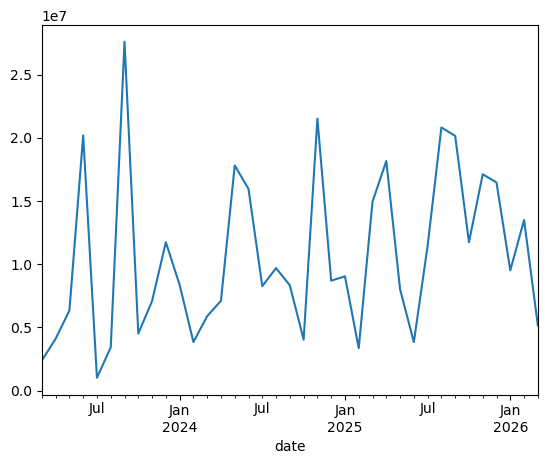

In [8]:

data1_df = pd.read_csv("it_projects_budget_data.csv",parse_dates=['start_date', 'end_date'])

data1_df['date'] = data1_df ['start_date']

data1_df  = data1_df.set_index('date')
data1_df  = data1_df.sort_index()

df_monthly = data1_df.resample('M').agg({
    'budget_actual': 'sum',
    'budget_planned': 'sum',
    'success_rate': 'mean'
})

df_monthly['delta'] = df_monthly['budget_actual'] - df_monthly['budget_planned']

df_monthly.budget_actual.plot()


#### Проверка стационарности временного ряда

Для корректного прогнозирования временного ряда необходимо проверить его стационарность. Для этого используется тест Дики-Фуллера (ADF — Augmented Dickey-Fuller).

Тест Дики-Фуллера проверяет наличие единичного корня во временном ряду. Стационарность означает, что статистические характеристики ряда (среднее, дисперсия) не меняются во времени

В нашем случае данные стационары: p=0.0

In [9]:

print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(df_monthly.budget_actual)[1])


Критерий Дики-Фуллера: p=0.000000


#### Декомпозиция временного ряда

Для глубокого анализа структуры временного ряда выполняется его декомпозиция — разложение на составляющие компоненты.

Тренд (Trend)	-    Долгосрочное направление движения ряда (рост, падение, стабильность)

Сезонность (Seasonal)	-   Регулярные повторяющиеся колебания (например, рост затрат в конце года)

Остаток (Residual)	-   Случайная составляющая — то, что не объясняется трендом и сезонностью

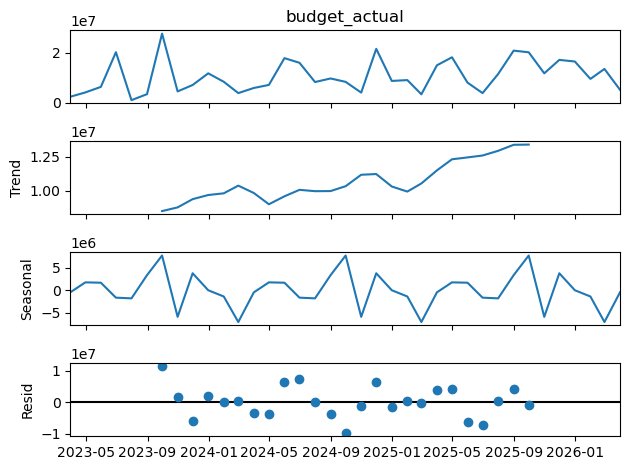

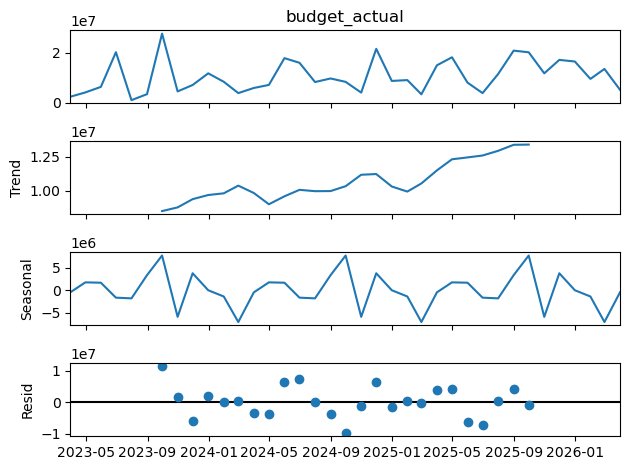

In [10]:
sm.tsa.seasonal_decompose(df_monthly.budget_actual).plot()

#### Преобразование Бокса-Кокса

Для стабилизации дисперсии и приведения данных к нормальному распределению применяется преобразование Бокса-Кокса.

In [11]:
df_monthly['boxcox'], lmbda = stats.boxcox(df_monthly.budget_actual)

#### Дифференцирование временного ряда

Для приведения временного ряда к стационарному виду выполняется дифференцирование — удаление тренда и сезонности.

In [12]:
df_monthly['diff1'] = df_monthly.boxcox - df_monthly.boxcox.shift(1)
df_monthly['diff_season'] = df_monthly.boxcox - df_monthly.boxcox.shift(12)

## 3.Построение прогноза с помощью линейной регрессии

Для прогнозирования бюджета используется простая линейная регрессия, которая моделирует зависимость затрат от времени.


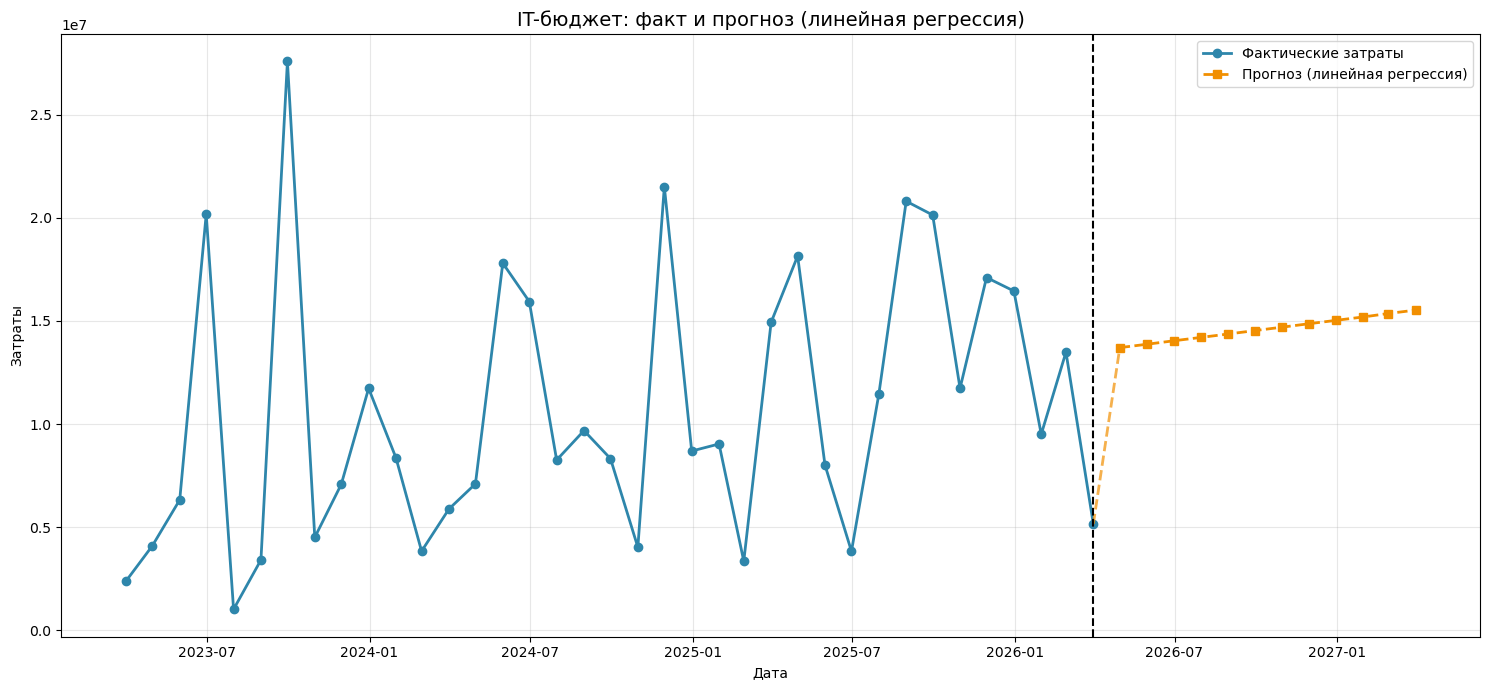

In [13]:
df2 = df_monthly[['budget_actual']].copy()

forecast_months = 12
date_list = [
    df2.index[-1] + relativedelta(months=x)
    for x in range(1, forecast_months + 1)
]

X = np.arange(len(df_monthly)).reshape(-1, 1)
y = df_monthly['budget_actual'].values

model_lr = LinearRegression()
model_lr.fit(X, y)


future_X = np.arange(len(df_monthly), len(df_monthly) + 12).reshape(-1, 1)
forecast_lr = model_lr.predict(future_X)

plt.figure(figsize=(15, 7))

plt.plot(df_monthly.index, df_monthly['budget_actual'], 
         label='Фактические затраты', 
         linewidth=2, 
         color='#2E86AB',
         marker='o')

plt.plot(date_list, forecast_lr, 
         label='Прогноз (линейная регрессия)', 
         linewidth=2, 
         color='#F18F01', 
         linestyle='--',
         marker='s')

plt.plot([df_monthly.index[-1], date_list[0]], 
         [df_monthly['budget_actual'].iloc[-1], forecast_lr[0]], 
         color='#F18F01', 
         linestyle='--', 
         linewidth=2,
         alpha=0.7)


plt.axvline(df_monthly.index[-1], color='black', linestyle='--', linewidth=1.5)

plt.title('IT-бюджет: факт и прогноз (линейная регрессия)', fontsize=14)
plt.ylabel('Затраты')
plt.xlabel('Дата')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Столбчатая диаграмма плановых и фактических затрат по категориям

Для визуализации сравнения плановых и фактических затрат используется встроенная функция Pandas для построения столбчатых диаграмм.


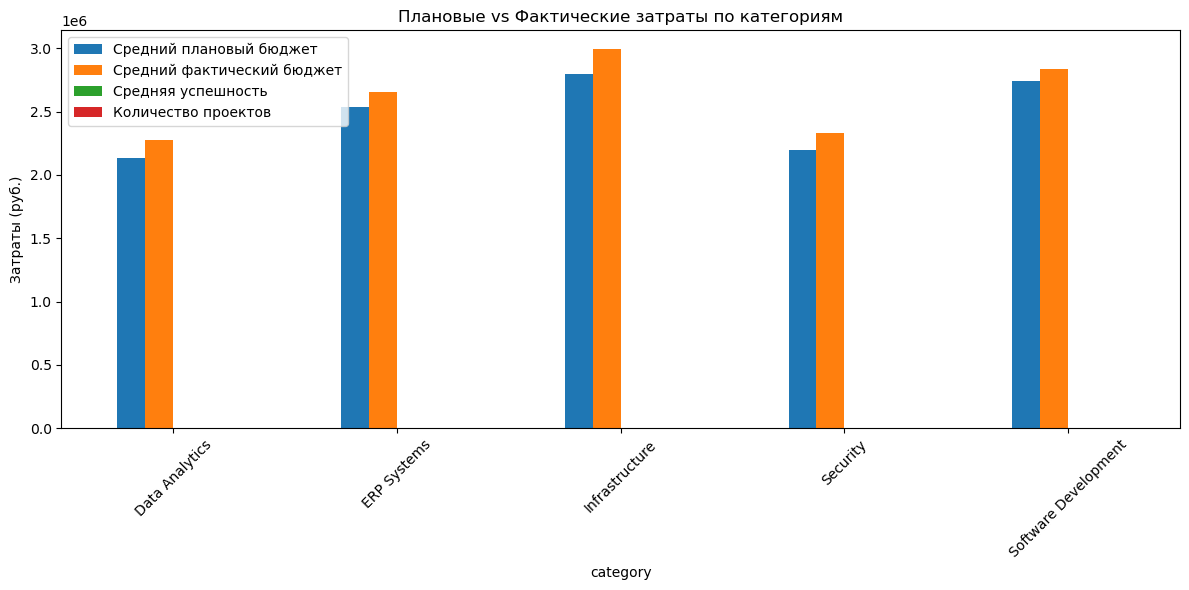

In [17]:
# Самый простой способ через pandas (встроенная визуализация)
category_stats .plot(kind='bar', figsize=(12, 6), 
                   title='Плановые vs Фактические затраты по категориям',
                   ylabel='Затраты (руб.)', rot=45)
plt.tight_layout()
plt.show()

#### Автоматический подбор параметров модели SARIMA

Для выбора оптимальных параметров модели используется автоматический поиск с помощью функции `auto_arima`.

In [ ]:

best = auto_arima(
    df_monthly.boxcox.dropna(),
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    information_criterion='aic'
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=513.563, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=511.930, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=511.572, Time=0.00 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=515.225, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=515.146, Time=0.03 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=510.096, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=511.874, Time=0.05 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=501.304, Time=0.01 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=503.254, Time=0.09 sec
 ARIMA(2,1,0)(0,0,1)[12] intercept   : AIC=503.250, Time=0.04 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=inf, T

#### Вывод оптимальных параметров модели SARIMA

После автоматического подбора гиперпараметров выполняется вывод наилучших значений для построения модели.

order=(p, d, q) - несезонная часть

seasonal_order=(P, D, Q, s)  сезонная часть


In [ ]:
print(f"order={best.order}, seasonal_order={best.seasonal_order}")


order=(2, 1, 1), seasonal_order=(0, 0, 0, 12)


#### Обучение модели SARIMAX

Для прогнозирования временного ряда используется модель SARIMAX, которая учитывает авторегрессию, интегрированность, скользящее среднее и внешние факторы.

In [ ]:
y = df_monthly['budget_actual']
exog = df_monthly[['budget_planned', 'success_rate']]

model_sarimax = sm.tsa.statespace.SARIMAX(
    y,
    exog=exog,
    order=(2,1,1),
    seasonal_order=(0,0,0,12)
).fit()

print(model_sarimax.summary())

                               SARIMAX Results                                
Dep. Variable:          budget_actual   No. Observations:                   37
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -530.243
Date:                Thu, 02 Apr 2026   AIC                           1072.486
Time:                        09:17:58   BIC                           1081.987
Sample:                    03-31-2023   HQIC                          1075.802
                         - 03-31-2026                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
budget_planned     1.0614      0.016     68.019      0.000       1.031       1.092
success_rate     -5.4e+06   8.27e-08  -6.53e+13      0.000    -5.4e+06    -5.4e+06
ar.L1              0.4835      0.246

#### Прогнозирование с помощью модели SARIMAX

Для построения прогноза используется статистическая модель SARIMAX, которая учитывает сезонность и внешние факторы.

In [ ]:
future_steps = 12

future_exog = exog.iloc[-future_steps:] 

sarimax_forecast = model_sarimax.predict(
    start=len(y),
    end=len(y)+future_steps-1,
    exog=future_exog
)

#### Создание признаков для модели машинного обучения

Для обучения модели XGBoost выполняется — создание дополнительных характеристик на основе исходных данных.

In [ ]:
df_feat = df_monthly.copy()

df_feat['month'] = df_feat.index.month
df_feat['year'] = df_feat.index.year

df_feat['lag1'] = df_feat['budget_actual'].shift(1)
df_feat['lag3'] = df_feat['budget_actual'].shift(3)
df_feat['lag12'] = df_feat['budget_actual'].shift(12)

df_feat['rolling_mean_3'] = df_feat['budget_actual'].rolling(3).mean()

df_feat = df_feat.dropna()

#### Подготовка признаков и обучение модели XGBoost

Для построения прогнозной модели выполняется формирование набора признаков и обучение градиентного бустинга.

In [ ]:

features = [
    'budget_planned', 'success_rate',
    'month', 'year',
    'lag1', 'lag3', 'lag12',
    'rolling_mean_3'
]

X = df_feat[features]
y = df_feat['budget_actual']

model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4
)

model_xgb.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Прогнозирование с помощью XGBoost (итеративный метод)

Для построения прогноза на 12 месяцев вперед используется итеративный подход, где каждое следующее предсказание опирается на предыдущие.

In [ ]:
df_future = df_feat.copy()

preds = []

for i in range(12):
    last_row = df_future.iloc[-1:].copy()

    last_row['lag1'] = df_future['budget_actual'].iloc[-1]
    last_row['lag3'] = df_future['budget_actual'].iloc[-3]
    last_row['lag12'] = df_future['budget_actual'].iloc[-12]

    pred = model_xgb.predict(last_row[features])[0]
    preds.append(pred)

    new_row = last_row.copy()
    new_row['budget_actual'] = pred
    df_future = pd.concat([df_future, new_row])

#### Ансамблевое прогнозирование

Для повышения точности прогноза выполняется объединение двух моделей: SARIMAX и XGBoost. Такой подход называется ансамблированием.


In [ ]:
final_forecast = 0.5 * sarimax_forecast.values + 0.5 * np.array(preds)

#### Визуализация прогноза бюджета

Для наглядного представления динамики затрат и прогнозных значений строится совмещенный график.

```python
plt.figure(figsize=(15, 7))

# Строим факт (исторические данные)
plt.plot(df_monthly.index, df_monthly['budget_actual'], 
         label='Фактические затраты', 
         linewidth=2, 
         color='#2E86AB',
         marker='o')

# Строим прогноз (отдельно)
plt.plot(date_list, final_forecast[:forecast_months], 
         label='Прогноз', 
         linewidth=2, 
         color='#F18F01', 
         linestyle='--',
         marker='s')

# Ручное соединение последней точки факта с первой точкой прогноза
plt.plot([df_monthly.index[-1], date_list[0]], 
         [df_monthly['budget_actual'].iloc[-1], final_forecast[0]], 
         color='#F18F01', 
         linestyle='--', 
         linewidth=2,
         alpha=0.7)

plt.axvline(df_monthly.index[-1], color='black', linestyle='--', linewidth=1.5)
plt.title('IT-бюджет: факт и прогноз', fontsize=14)
plt.ylabel('Затраты')
plt.xlabel('Дата')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

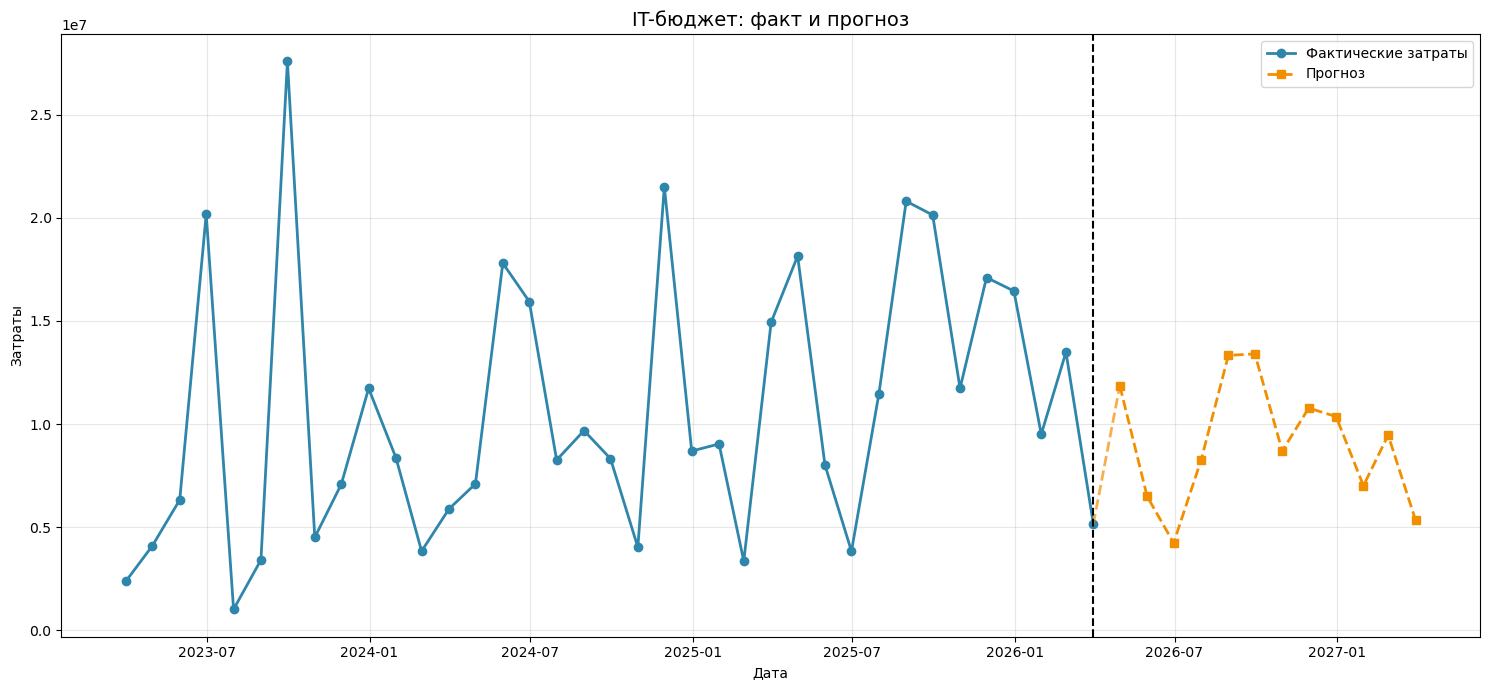

In [ ]:


future = pd.DataFrame(index=date_list, columns=df2.columns)
df2 = pd.concat([df2, future])

df2.loc[date_list, 'forecast'] = final_forecast[:forecast_months]

plt.figure(figsize=(15, 7))

plt.plot(df_monthly.index, df_monthly['budget_actual'], 
         label='Фактические затраты', 
         linewidth=2, 
         color='#2E86AB',
         marker='o')

plt.plot(date_list, final_forecast[:forecast_months], 
         label='Прогноз', 
         linewidth=2, 
         color='#F18F01', 
         linestyle='--',
         marker='s')

plt.plot([df_monthly.index[-1], date_list[0]], 
         [df_monthly['budget_actual'].iloc[-1], final_forecast[0]], 
         color='#F18F01', 
         linestyle='--', 
         linewidth=2,
         alpha=0.7)

plt.axvline(df_monthly.index[-1], color='black', linestyle='--', linewidth=1.5)
plt.title('IT-бюджет: факт и прогноз', fontsize=14)
plt.ylabel('Затраты')
plt.xlabel('Дата')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()